In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import  silhouette_score
from sklearn import datasets
from scipy.cluster.hierarchy import dendrogram, linkage 
from scipy.cluster.hierarchy import dendrogram
from yellowbrick.cluster import SilhouetteVisualizer
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
import warnings
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'C:\Users\enadi\Desktop\DataScienceBootcamp\jupiter\data/energy_utilities_sim.csv')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        1253 non-null   int64  
 1   average_daily_consumption      1253 non-null   float64
 2   average_days_to_bill_payment   1253 non-null   float64
 3   customer_since                 1253 non-null   str    
 4   area                           1253 non-null   float64
 5   age                            1253 non-null   str    
 6   marital_status                 1253 non-null   str    
 7   educational_level              1253 non-null   str    
 8   prefecture                     1253 non-null   str    
 9   average_monthly_visits         1253 non-null   float64
 10  average_web_monthly_visits     1253 non-null   float64
 11  average_mobile_monthly_visits  1253 non-null   float64
dtypes: float64(6), int64(1), str(5)
memory usage: 117.6 KB


In [5]:
df.head()

,user_id,average_daily_consumption,average_days_to_bill_payment,customer_since,area,age,marital_status,educational_level,prefecture,average_monthly_visits,average_web_monthly_visits,average_mobile_monthly_visits
0,1,7.797533,-33.932899,2015-05-14,136.200805,40-55,Married,Master’s degree,Neon-Attika,0.865182,0.538854,0.330131
1,2,25.068224,-3.213220,2015-06-02,97.656313,30-39,Married,Bachelor’s degree,Corinthus Crossroads,4.154858,0.697384,3.491964
2,3,7.875073,16.366928,2015-06-29,133.072322,40-55,Married,Master’s degree,Neon-Attika,2.819235,2.394294,0.560970
3,4,12.309787,-2.479825,2015-03-19,88.884085,40-55,Married,Master’s degree,Neon-Attika,0.852767,0.569274,0.238127
4,5,8.888037,14.005530,2014-08-22,64.459468,30-39,Married,Bachelor’s degree,Evoa Conglomerate,11.056524,3.527665,7.131606


In [6]:
df["age"].unique()

<StringArray>
['40-55', '30-39', '19-29', '68+', '56-67', '18 or younger']
Length: 6, dtype: str

In [7]:
df["area"].unique()

array([136.2008052 ,  97.65631283, 133.0723222 , ...,  81.664547  ,
       120.466909  , 112.3299865 ], shape=(1244,))

In [8]:
print((df["area"] == 0).sum())
print((df["area"] == 0).mean() * 100)   # as a percentage of all rows

10
0.7980845969672785


In [9]:
print("Before:", df.shape)
df = df[df["area"] != 0]
print("After:", df.shape)

Before: (1253, 12)
After: (1243, 12)


In [10]:
df["marital_status"].unique()

<StringArray>
['Married', 'Single', 'Widowed', 'Divorced']
Length: 4, dtype: str

In [11]:
df["marital_status"].value_counts()

marital_status
Married     906
Single      273
Divorced     48
Widowed      16
Name: count, dtype: int64

In [12]:
print(df["educational_level"].value_counts())
print(df["age"].value_counts())
print(df["prefecture"].value_counts())

educational_level
Bachelor’s degree                                  511
High school graduate, diploma or the equivalent    437
Master’s degree                                    238
Doctorate degree                                    29
No degree                                           28
Name: count, dtype: int64
age
30-39            509
40-55            504
19-29            130
56-67             78
68+               20
18 or younger      2
Name: count, dtype: int64
prefecture
Neon-Attika             778
Thessalon Prime         104
Heracles Prime           35
Voitron                  24
Achaon Convergence       23
Ioantrix                 18
Magnetos Syndicate       17
Corinthus Crossroads     16
Aitol Nexus              16
Evrax                    15
Evoa Conglomerate        14
Chanion Underhive        14
Kavallon                 11
Phthion                   9
Lasitron                  9
Heartsteel Sector         8
Xanthion                  8
Copper-Forged             8
Pierion   

In [13]:
df.describe()

,user_id,average_daily_consumption,average_days_to_bill_payment,area,average_monthly_visits,average_web_monthly_visits,average_mobile_monthly_visits
count,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000
mean,627.542237,15.858281,3.612800,99.969210,10.649159,2.318237,8.309946
std,362.216418,16.989987,9.871939,55.946046,11.144077,3.051626,10.211820
min,1.000000,0.000000,-101.375745,9.324504,0.403867,0.058103,0.091780
25%,313.500000,8.037733,0.155256,69.565065,3.934029,0.506382,2.173200
50%,627.000000,11.833520,3.504459,91.567059,7.182262,1.229221,5.025437
75%,941.500000,17.709515,8.393601,115.726409,13.221938,2.727871,10.447661
max,1253.000000,193.204260,28.739392,635.552930,84.147598,31.680225,85.037754


In [14]:
print("Number of early payers:", (df["average_days_to_bill_payment"] < 0).sum())
df[df["average_days_to_bill_payment"] < 0]["average_days_to_bill_payment"].describe()


Number of early payers: 233


count    233.000000
mean      -8.273222
std       14.691897
min     -101.375745
25%       -9.462727
50%       -2.727306
75%       -0.891435
max       -0.088369
Name: average_days_to_bill_payment, dtype: float64

In [15]:
len(df[df["average_days_to_bill_payment"] < -30])

16

In [16]:
(df["average_days_to_bill_payment"] > 0).sum()

np.int64(938)

## Payment behavior: early, on time, or late


In [17]:
import numpy as np

df["payment_behavior"] = np.select(
    [df["average_days_to_bill_payment"] < 0,
     df["average_days_to_bill_payment"] > 0],
    ["Early", "Late"],
    default="On time"
)

In [18]:
counts = df["payment_behavior"].value_counts()
print(counts)

payment_behavior
Late       938
Early      233
On time     72
Name: count, dtype: int64


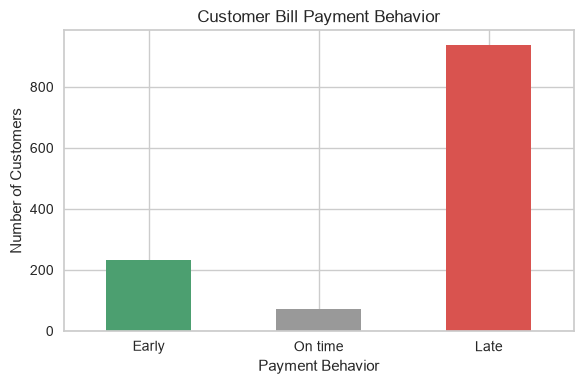

In [19]:
import matplotlib.pyplot as plt

counts = counts.reindex(["Early", "On time", "Late"])  

plt.figure(figsize=(6,4))
counts.plot(kind="bar", color=["#4C9F70", "#999999", "#D9534F"])
plt.title("Customer Bill Payment Behavior")
plt.xlabel("Payment Behavior")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

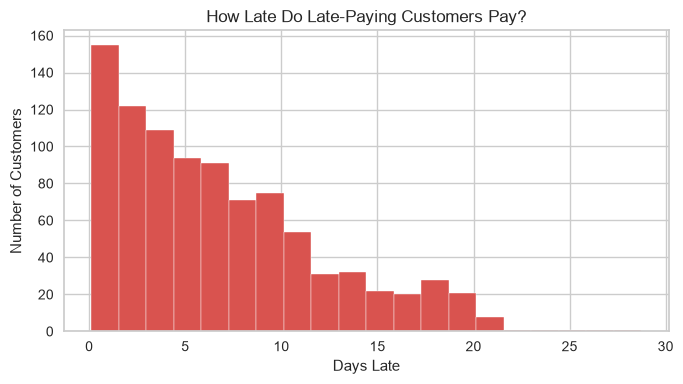

In [20]:
late_payers = df[df["average_days_to_bill_payment"] > 0]["average_days_to_bill_payment"]

plt.figure(figsize=(7,4))
plt.hist(late_payers, bins=20, color="#D9534F", edgecolor="white")
plt.title("How Late Do Late-Paying Customers Pay?")
plt.xlabel("Days Late")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [21]:
late_payers_df = df[df["average_days_to_bill_payment"] > 0]

print(late_payers_df.shape)
late_payers_df.head()

(938, 13)


,user_id,average_daily_consumption,average_days_to_bill_payment,customer_since,area,age,marital_status,educational_level,prefecture,average_monthly_visits,average_web_monthly_visits,average_mobile_monthly_visits,payment_behavior
2,3,7.875073,16.366928,2015-06-29,133.072322,40-55,Married,Master’s degree,Neon-Attika,2.819235,2.394294,0.560970,Late
4,5,8.888037,14.005530,2014-08-22,64.459468,30-39,Married,Bachelor’s degree,Evoa Conglomerate,11.056524,3.527665,7.131606,Late
5,6,19.605566,1.398081,2015-03-12,60.507393,19-29,Married,Bachelor’s degree,Voitron,5.911658,2.261419,3.419086,Late
6,7,9.567542,14.594737,2015-09-25,110.163674,30-39,Married,Bachelor’s degree,Neon-Attika,5.439528,2.522254,3.207347,Late
7,8,15.926072,11.600238,2015-02-03,74.721484,40-55,Single,Bachelor’s degree,Neon-Attika,4.273455,0.267400,4.120846,Late


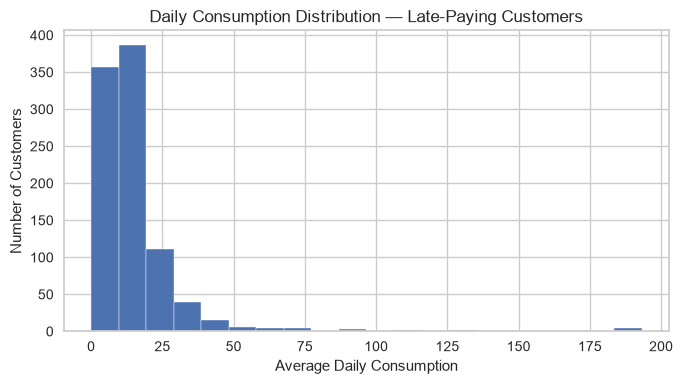

In [22]:
plt.figure(figsize=(7,4))
plt.hist(late_payers_df["average_daily_consumption"], bins=20, color="#4C72B0", edgecolor="white")
plt.title("Daily Consumption Distribution — Late-Paying Customers")
plt.xlabel("Average Daily Consumption")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [23]:
print(late_payers_df["average_daily_consumption"].mean())
print(df["average_daily_consumption"].mean())

15.622014413019189
15.858281341520515


area vs. consumption

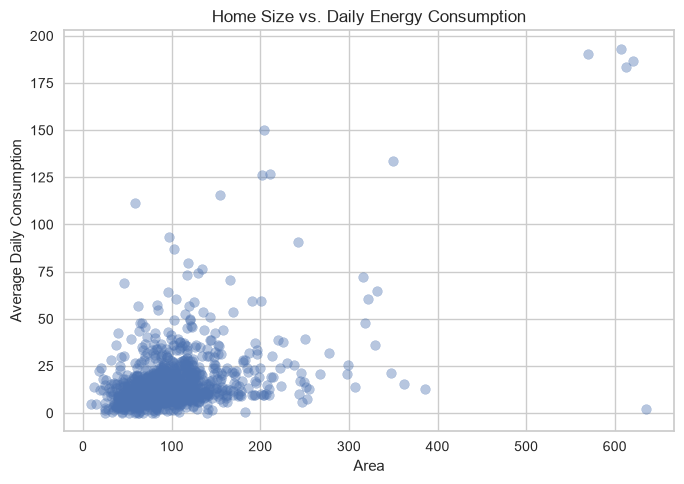

In [24]:
plt.figure(figsize=(7,5))
plt.scatter(df["area"], df["average_daily_consumption"], alpha=0.4, color="#4C72B0")
plt.title("Home Size vs. Daily Energy Consumption")
plt.xlabel("Area")
plt.ylabel("Average Daily Consumption")
plt.tight_layout()
plt.show()

In [25]:
df["area"].corr(df["average_daily_consumption"])

np.float64(0.5188350320680662)

In [26]:
age_order = ["18 or younger", "19-29", "30-39", "40-55", "56-67", "68+"]

web_by_age = df.groupby("age")["average_web_monthly_visits"].mean().reindex(age_order)
mobile_by_age = df.groupby("age")["average_mobile_monthly_visits"].mean().reindex(age_order)

print(web_by_age)
print(mobile_by_age)

age
18 or younger    2.103646
19-29            2.073983
30-39            2.326213
40-55            2.188487
56-67            3.487638
68+              2.433423
Name: average_web_monthly_visits, dtype: float64
age
18 or younger     1.486766
19-29             7.848467
30-39             8.492510
40-55             7.344713
56-67            13.295898
68+              12.224319
Name: average_mobile_monthly_visits, dtype: float64


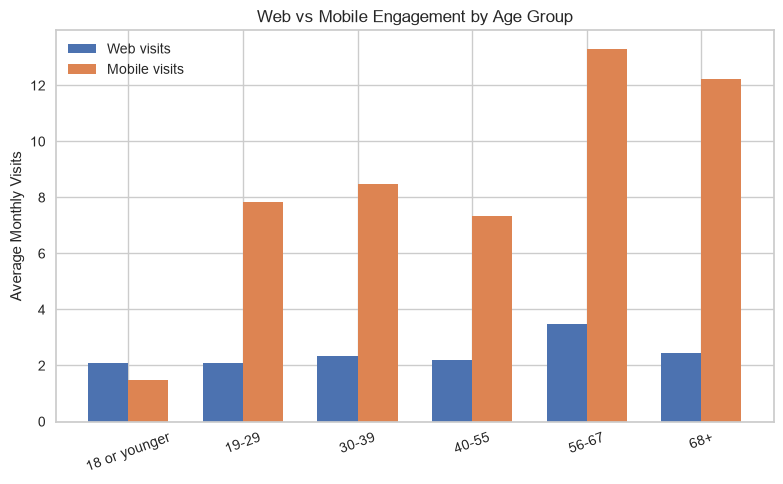

In [27]:
x = np.arange(len(age_order))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, web_by_age, width, label="Web visits", color="#4C72B0")
plt.bar(x + width/2, mobile_by_age, width, label="Mobile visits", color="#DD8452")

plt.xticks(x, age_order, rotation=20)
plt.ylabel("Average Monthly Visits")
plt.title("Web vs Mobile Engagement by Age Group")
plt.legend()
plt.tight_layout()
plt.show()

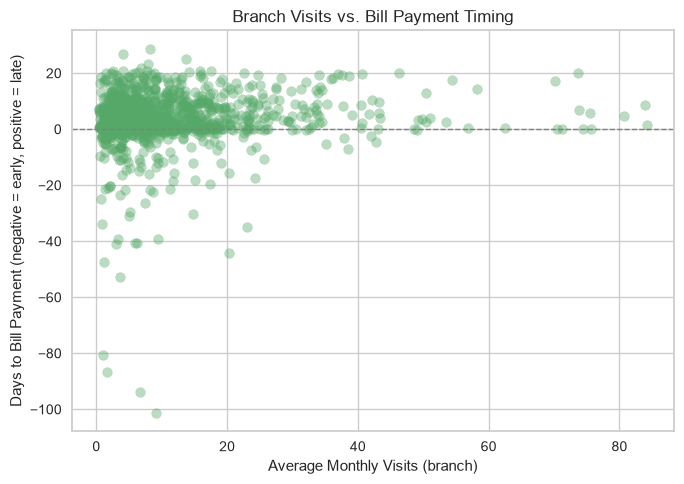

In [28]:
plt.figure(figsize=(7,5))
plt.scatter(df["average_monthly_visits"], df["average_days_to_bill_payment"], alpha=0.4, color="#55A868")
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.title("Branch Visits vs. Bill Payment Timing")
plt.xlabel("Average Monthly Visits (branch)")
plt.ylabel("Days to Bill Payment (negative = early, positive = late)")
plt.tight_layout()
plt.show()

In [29]:
# Caution: this uses the RAW prefecture column (47 categories).
# Several prefectures have very few customers (some under 5), so their
# averages here are unreliable. See the "prefecture_grouped" version
# further down, which merges small prefectures into "Other" first.
mean_consumption_by_prefecture = (
    df.groupby("prefecture")["average_daily_consumption"]
    .mean()
    .sort_values(ascending=False)
)

print(mean_consumption_by_prefecture)


prefecture
Dramasynth              30.062291
Kilkian                 28.844434
Laristron               28.248976
Rethyx-Pterax           26.561827
Kastor                  25.500479
Serronex                25.162693
Ioantrix                24.367185
Chanion Underhive       24.360491
Xanthion                23.569839
Kavallon                23.038179
Evrax                   21.234560
Hemathron               20.326520
Pellaxis                19.147763
Pierion                 18.915015
Cephalpod               18.877994
Spartan Laconix         18.004216
Corinthus Crossroads    17.989070
Lasitron                17.712009
Hileon                  17.593198
Achaon Convergence      16.993663
Heracles Prime          16.686991
Messonex                16.317305
Thessalon Prime         16.243831
Cyclotron               16.201938
Argolith Supreme        15.896849
Neon-Attika             15.370276
Evoa Conglomerate       15.200529
Eurytan                 14.937928
Zakynthia               13.724108
Voi

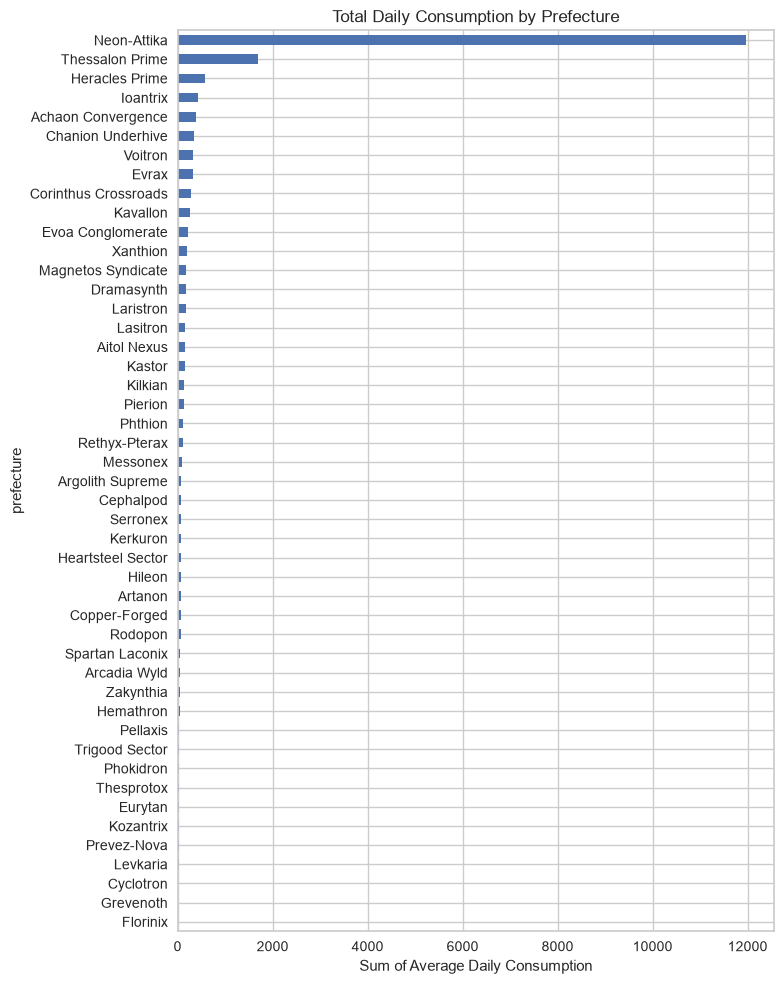

In [30]:
total_consumption_by_prefecture = (
    df.groupby("prefecture")["average_daily_consumption"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,10))
total_consumption_by_prefecture.plot(kind="barh", color="#4C72B0")
plt.title("Total Daily Consumption by Prefecture")
plt.xlabel("Sum of Average Daily Consumption")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


age
18 or younger      2
19-29            130
30-39            509
40-55            504
56-67             78
68+               20
Name: count, dtype: int64


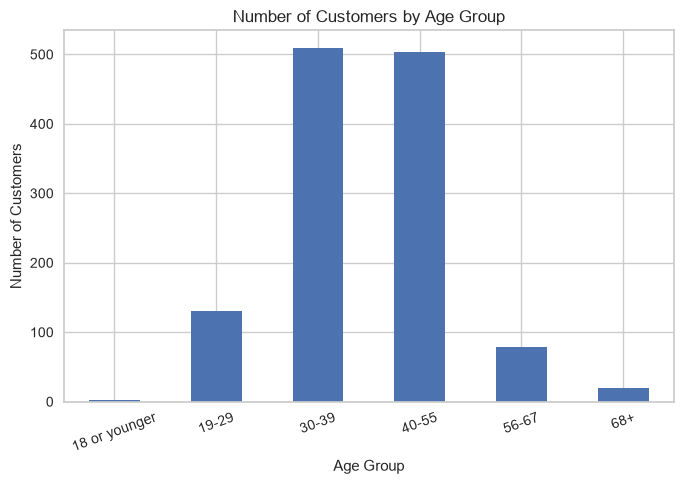

In [31]:
age_order = ["18 or younger", "19-29", "30-39", "40-55", "56-67", "68+"]
customers_by_age = df["age"].value_counts().reindex(age_order)

print(customers_by_age)

plt.figure(figsize=(7,5))
customers_by_age.plot(kind="bar", color="#4C72B0")
plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [32]:
counts = df["prefecture"].value_counts()
keep = counts[counts >= 14].index

df["prefecture_grouped"] = df["prefecture"].where(df["prefecture"].isin(keep), "Other")

customers_by_prefecture_grouped = df["prefecture_grouped"].value_counts()
print(customers_by_prefecture_grouped)

prefecture_grouped
Neon-Attika             778
Other                   169
Thessalon Prime         104
Heracles Prime           35
Voitron                  24
Achaon Convergence       23
Ioantrix                 18
Magnetos Syndicate       17
Corinthus Crossroads     16
Aitol Nexus              16
Evrax                    15
Evoa Conglomerate        14
Chanion Underhive        14
Name: count, dtype: int64


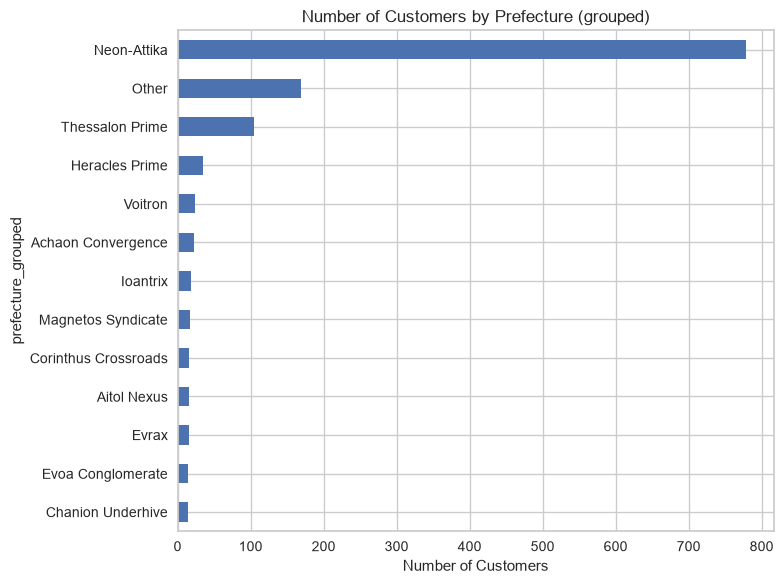

In [33]:
plt.figure(figsize=(8,6))
customers_by_prefecture_grouped.plot(kind="barh", color="#4C72B0")
plt.title("Number of Customers by Prefecture (grouped)")
plt.xlabel("Number of Customers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

prefecture_grouped
Ioantrix                24.367185
Chanion Underhive       24.360491
Evrax                   21.234560
Corinthus Crossroads    17.989070
Achaon Convergence      16.993663
Other                   16.708750
Heracles Prime          16.686991
Thessalon Prime         16.243831
Neon-Attika             15.370276
Evoa Conglomerate       15.200529
Voitron                 13.590756
Magnetos Syndicate      10.855103
Aitol Nexus              9.763159
Name: average_daily_consumption, dtype: float64


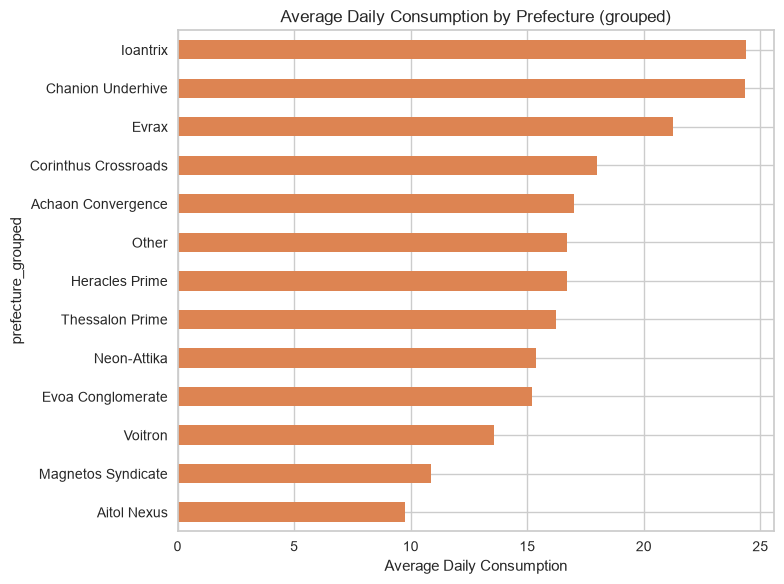

In [34]:
mean_consumption_by_prefecture_grouped = (
    df.groupby("prefecture_grouped")["average_daily_consumption"]
    .mean()
    .sort_values(ascending=False)
)

print(mean_consumption_by_prefecture_grouped)

plt.figure(figsize=(8,6))
mean_consumption_by_prefecture_grouped.plot(kind="barh", color="#DD8452")
plt.title("Average Daily Consumption by Prefecture (grouped)")
plt.xlabel("Average Daily Consumption")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

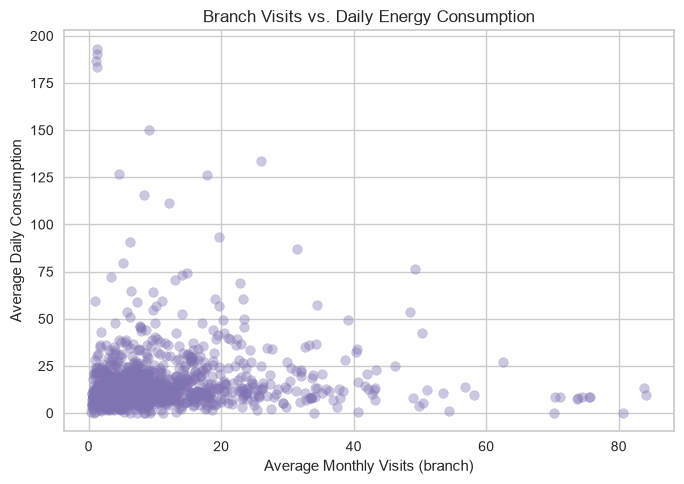

In [35]:
plt.figure(figsize=(7,5))
plt.scatter(df["average_monthly_visits"], df["average_daily_consumption"], alpha=0.4, color="#8172B2")
plt.title("Branch Visits vs. Daily Energy Consumption")
plt.xlabel("Average Monthly Visits (branch)")
plt.ylabel("Average Daily Consumption")
plt.tight_layout()
plt.show()